# DCT Autoencoder — Tutorial

This notebook walks through **`dct-autoencoder`**: a non-trainable, analytically defined autoencoder for RGB images that reproduces the core ideas behind JPEG compression.

## Table of Contents

1. [Overview](#Overview)
2. [Mathematical Background](#Mathematical-Background)
   - [Color Space Conversion](#Color-Space-Conversion)
   - [The 2-D Discrete Cosine Transform](#The-2-D-Discrete-Cosine-Transform)
   - [DCT Basis Functions](#DCT-Basis-Functions)
   - [Normalisation Factors](#Normalisation-Factors)
3. [The `DCTBasis` Object](#The-DCTBasis-Object)
4. [The `DCTAutoencoder` Module](#The-DCTAutoencoder-Module)
   - [Initialisation and Kernel Sorting](#Initialisation-and-Kernel-Sorting)
   - [Encoding](#Encoding)
   - [Decoding](#Decoding)
   - [Compression](#Compression)
   - [Decompression](#Decompression)
5. [Interactive Walkthrough](#Interactive-Walkthrough)
6. [Compression Ratio Analysis](#Compression-Ratio-Analysis)

## Overview

`dct-autoencoder` is a **non-trainable, analytically defined autoencoder** for RGB images. It reproduces the core algorithmic ideas behind JPEG by:

1. Converting RGB pixels to the **YCbCr** colour space, which separates luminance (perceptually more important) from chrominance.
2. Partitioning each channel into non-overlapping **8 × 8 blocks** (or blocks of any chosen size) and applying the **2-D Discrete Cosine Transform (DCT)** to each block via a strided convolution.
3. Optionally **zeroing high-frequency DCT coefficients** to achieve lossy compression.

Because the transform is perfectly invertible (up to floating-point precision), the autoencoder is **lossless by default**; lossy compression is an opt-in feature controlled at construction time.

## Mathematical Background

### Color Space Conversion

RGB channels carry highly correlated information. The human visual system is far more sensitive to changes in brightness than to changes in hue. Converting to **YCbCr** exploits this by separating:

- **Y** — luminance (perceived brightness)
- **Cb** — blue-difference chrominance
- **Cr** — red-difference chrominance

The forward transform (implemented in `rgb_to_ycbcr`) is:

$$
Y  = 0.299\,R + 0.587\,G + 0.114\,B
$$

$$
C_b = (B - Y) \cdot 0.564 + 0.5
$$

$$
C_r = (R - Y) \cdot 0.713 + 0.5
$$

The 0.5 offset keeps all values in the range $[0, 1]$ when the input is in $[0, 1]$.

The **inverse** transform (implemented in `ycbcr_to_rgb`) recovers RGB from YCbCr:

$$
R = Y + 1.40252\,(C_r - 0.5)
$$

$$
G = Y - 0.71440\,(C_r - 0.5) - 0.34434\,(C_b - 0.5)
$$

$$
B = Y + 1.77305\,(C_b - 0.5)
$$

> **Note:** The coefficients are derived from the exact matrix inverse, so the round-trip is numerically exact (within floating-point precision) for in-range values.

### The 2-D Discrete Cosine Transform

For an $N \times N$ image block, the **Type-II 2-D DCT** maps spatial pixel values $f(x, y)$ to frequency-domain coefficients $F(u, v)$:

$$
F(u, v) = \frac{2}{N}\, C(u)\, C(v)
\sum_{x=0}^{N-1} \sum_{y=0}^{N-1}
f(x, y)
\cos\!\left(\frac{(2x+1)\,u\,\pi}{2N}\right)
\cos\!\left(\frac{(2y+1)\,v\,\pi}{2N}\right)
$$

where the normalisation constants are

$$
C(k) =
\begin{cases}
\dfrac{1}{\sqrt{2}} & k = 0 \\[6pt]
1                   & k > 0
\end{cases}
$$

The inverse DCT (IDCT) reconstructs pixel values from coefficients:

$$
f(x, y) = \frac{2}{N}
\sum_{u=0}^{N-1} \sum_{v=0}^{N-1}
C(u)\,C(v)\,F(u, v)
\cos\!\left(\frac{(2x+1)\,u\,\pi}{2N}\right)
\cos\!\left(\frac{(2y+1)\,v\,\pi}{2N}\right)
$$

For a standard 8 × 8 block ($N=8$) there are **64 basis functions**, one for each frequency pair $u, v$ with $u, v \in \{0, 1, \ldots, 7\}$.

### DCT Basis Functions

Each basis function $\phi_{u,v}(x,y)$ is the outer product of two 1-D cosine waves:

$$
\phi_{u,v}(x, y)
= \cos\!\left(\frac{(2x+1)\,u\,\pi}{2N}\right)
  \cos\!\left(\frac{(2y+1)\,v\,\pi}{2N}\right)
$$

- When $u = v = 0$ the basis function is a **flat (DC) patch** — it captures the average grey level of the block.
- As $u$ or $v$ increases, the function oscillates more rapidly, capturing progressively finer detail.

The **spatial frequency magnitude** associated with $(u, v)$ is simply the Euclidean norm:

$$
\|\mathbf{f}_{u,v}\| = \sqrt{u^2 + v^2}
$$

The autoencoder sorts all $N^2$ kernels in ascending order of $\|\mathbf{f}_{u,v}\|$, so **channel 0 is always the DC component** and the last channels correspond to the finest spatial detail.

### Normalisation Factors

`get_dct_basis` computes two factors that together reproduce the DCT coefficient exactly:

| Symbol | Expression | Role |
|--------|-----------|------|
| scalar $\alpha$ | $\dfrac{2}{N}$ | Shared prefactor for every coefficient |
| matrix $M_{u,v}$ | $C(u) \cdot C(v)$ | Per-frequency DC/AC weight ($\tfrac{1}{\sqrt{2}}$ when either index is 0, else 1) |

The full coefficient is

$$
F(u,v) = \alpha \cdot M_{u,v} \cdot \langle f, \phi_{u,v} \rangle
$$

where $\langle f, \phi_{u,v} \rangle$ is the convolution inner product computed by PyTorch's `F.conv2d`.

---

## Setup

Run this cell once to import dependencies and configure plotting.

In [1]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision.transforms.functional import to_pil_image, to_tensor
from visualization import visualize_dct_basis_functions

from dct_autoencoder import DCTAutoencoder, DCTBasis, get_dct_basis

## The `DCTBasis` Object

The basis object holds all analytical DCT quantities for a given block size $N$:

```python
from dct_autoencoder import get_dct_basis, DCTBasis

basis: DCTBasis = get_dct_basis(block_size=8)
```

| Field | Shape | Description |
|-------|-------|-------------|
| `basis_functions` | `(N, N, N, N)` | All $N^2$ 2-D cosine patches, indexed as `[v, u, y, x]` |
| `spatial_frequencies_components` | `(N, N, 2)` | Integer frequency pair $(v, u)$ for every basis function |
| `spatial_frequencies_magnitude` | `(N, N)` | $\sqrt{u^2 + v^2}$ for every basis function |
| `multiplication_factor_matrix` | `(N, N)` | $C(u) \cdot C(v)$ for every $(u, v)$ |
| `multiplication_factor_scalar` | `float` | $\tfrac{2}{N}$ |
| `block_size` | `int` | $N$ |

In [2]:
dct_basis: DCTBasis = get_dct_basis(block_size=8)

print(f"{dct_basis.basis_functions.shape=}")
print(f"{dct_basis.spatial_frequencies_components.shape=}")
print(f"{dct_basis.spatial_frequencies_magnitude.shape=}")
print(f"{dct_basis.multiplication_factor_matrix.shape=}")
print(f"{dct_basis.multiplication_factor_scalar=}")
print(f"{dct_basis.block_size=}")

dct_basis.basis_functions.shape=(8, 8, 8, 8)
dct_basis.spatial_frequencies_components.shape=(8, 8, 2)
dct_basis.spatial_frequencies_magnitude.shape=(8, 8)
dct_basis.multiplication_factor_matrix.shape=(8, 8)
dct_basis.multiplication_factor_scalar=0.25
dct_basis.block_size=8


Visualising all 64 basis functions for an 8 × 8 block (top-left = DC, bottom-right = highest frequency):

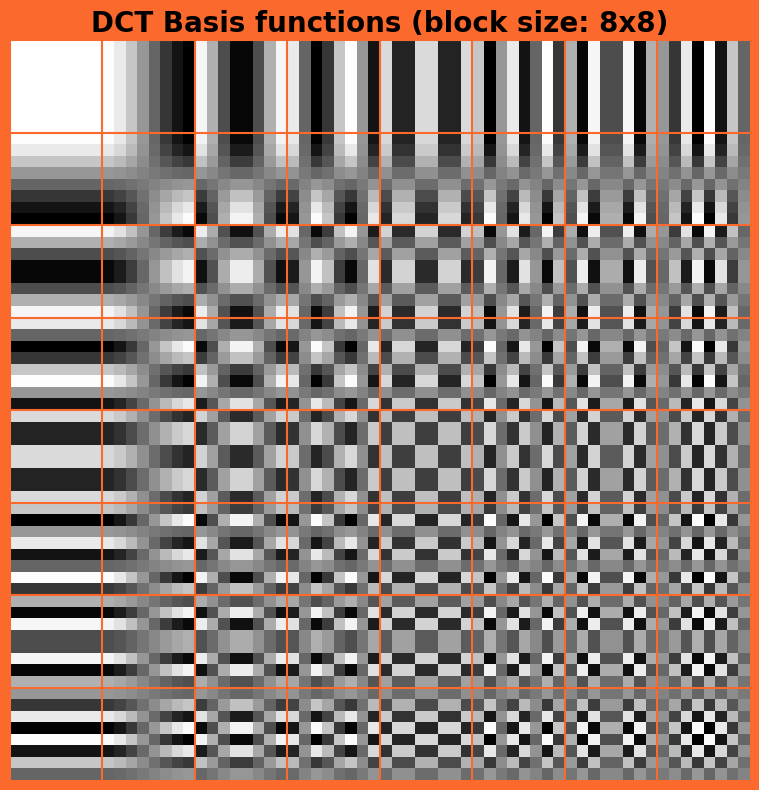

In [3]:
fig, ax = visualize_dct_basis_functions(dct_basis)
plt.show()

## The `DCTAutoencoder` Module

```python
from dct_autoencoder import DCTAutoencoder

model = DCTAutoencoder(
    block_size=8,
    num_luminance_compressed_channels=None,   # keep all 64 Y  frequencies
    num_chrominance_compressed_channels=None, # keep all 64 Cb/Cr frequencies
)
```

### Constructor Parameters

| Parameter | Default | Effect |
|-----------|---------|--------|
| `block_size` | `8` | Size of non-overlapping DCT blocks |
| `num_luminance_compressed_channels` | `None` | How many low-frequency Y coefficients to retain (`None` = all) |
| `num_chrominance_compressed_channels` | `None` | How many low-frequency Cb/Cr coefficients to retain (`None` = all) |

After construction the model has:

- `embedding_dimension` — total number of output channels per spatial position: $N^2 \times 3$ (Y + Cb + Cr each contribute $N^2$ channels).
- All DCT kernels stored as **non-trainable buffers** (`register_buffer`), so they automatically move to the correct device when you call `.to(device)`.

### Initialisation and Kernel Sorting

During `__init__` the $N^2$ kernels are sorted by ascending spatial frequency magnitude. This is a key design choice: it guarantees that **the first $k$ channels always correspond to the $k$ lowest spatial frequencies**, making channel-wise truncation equivalent to low-pass filtering.

```
channel 0  →  (u=0, v=0)  →  DC (flat)        ‖f‖ = 0
channel 1  →  (u=1, v=0)  →  slow horizontal  ‖f‖ = 1
channel 2  →  (u=0, v=1)  →  slow vertical    ‖f‖ = 1
...
channel 63 →  (u=7, v=7)  →  finest detail    ‖f‖ ≈ 9.9
```

### Encoding

```python
# rgb_images_batch: (B, 3, H, W),  values in [0, 1]
encodings = model.encode(rgb_images_batch)
# encodings: (B, 3*N², H//N, W//N)
```

**Step-by-step pipeline:**

1. **RGB → YCbCr** — $\text{ycbcr} = \text{rgb\_to\_ycbcr}(\text{rgb})$
2. **Normalise to** $[-1, 1]$ — $\text{ycbcr} \leftarrow 2 \cdot \text{ycbcr} - 1$
3. **Block-wise DCT via strided convolution** — for each channel $c \in \{Y, C_b, C_r\}$:

$$
\text{enc}_c = \alpha \cdot M \cdot \texttt{conv2d}(c,\, \{\phi_{u,v}\},\, \text{stride}=N)
$$

4. **Scale down by** $N$ — $\text{enc} \leftarrow \text{enc} / N$
5. **Concatenate channels** — $\text{enc} = [\text{enc}_Y \| \text{enc}_{C_b} \| \text{enc}_{C_r}]$, shape $(B,\, 3N^2,\, H/N,\, W/N)$.

### Decoding

```python
rgb_reconstructed = model.decode(encodings)
# rgb_reconstructed: (B, 3, H, W),  values in [0, 1]  (clamped)
```

Decoding is the exact inverse of encoding:

1. **Scale up by** $N$ — $\text{enc} \leftarrow \text{enc} \times N$
2. **Split channels** into $Y$, $C_b$, $C_r$ sub-tensors of $N^2$ channels each.
3. **Block-wise IDCT via transposed strided convolution** — for each channel:

$$
c = \alpha \cdot \texttt{conv\_transpose2d}(M \cdot \text{enc}_c,\, \{\phi_{u,v}\},\, \text{stride}=N)
$$

4. **Denormalise** — $\text{ycbcr} \leftarrow \text{ycbcr} / 2 + 0.5$
5. **YCbCr → RGB** — $\text{rgb} = \text{ycbcr\_to\_rgb}(\text{ycbcr})$ (output clamped to $[0, 1]$).

### Compression

```python
compressed = model.compress(encodings)
# compressed: (B, lum_passband + 2*chr_passband, H//N, W//N)
```

Compression **discards high-frequency coefficients** by Boolean masking:

- `compression_luminance_mask` — `True` for the first `num_luminance_compressed_channels` positions (= the lowest frequencies).
- `compression_chrominance_mask` — analogous for Cb and Cr.

Mathematically, if $k_Y$ luminance and $k_C$ chrominance coefficients are kept:

$$
\tilde{\mathbf{F}}_Y = \{F_Y(u,v) : \text{rank}(u,v) < k_Y\}
$$

$$
\tilde{\mathbf{F}}_{C_b}, \tilde{\mathbf{F}}_{C_r} = \{F_c(u,v) : \text{rank}(u,v) < k_C\}
$$

where "rank" refers to the sorted order by $\sqrt{u^2+v^2}$.

> If no compression parameters were set at construction, `compress` is a no-op and returns the input unchanged.

### Decompression

```python
encodings_recovered = model.decompress(compressed)
# encodings_recovered: (B, 3*N², H//N, W//N)  — same shape as encode() output
```

Decompression **re-inserts zeros** for the discarded high-frequency coefficients, then the result can be passed to `decode()`:

```python
compressed   = model.compress(model.encode(images))
decompressed = model.decompress(compressed)
reconstructed = model.decode(decompressed)
```

---

## Interactive Walkthrough

The cells below load a test image and run the full encode → compress → decompress → decode pipeline. Adjust `block_size` and compression settings to explore the trade-off between quality and size.

### Load a test image

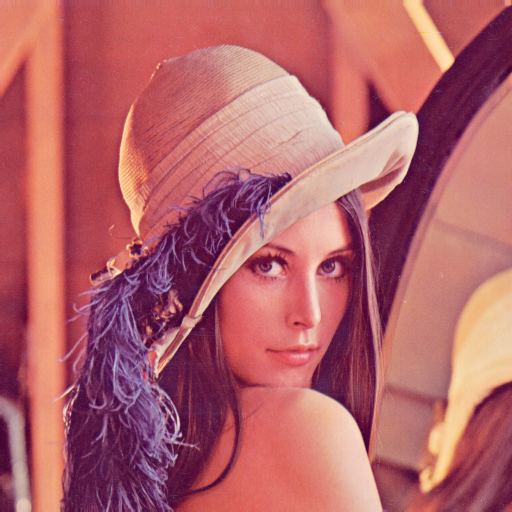

In [4]:
image = Image.open("./test_images/Lenna_(test_image).png")
image

### Part 1 — Lossless round-trip

With no compression parameters, encode → decode should recover the original image (within floating-point tolerance).

embedding_dimension = 192
is nn.Module: True
batch.shape=torch.Size([1, 3, 512, 512])
enc.shape=torch.Size([1, 192, 64, 64])
Max reconstruction error: 0.000001


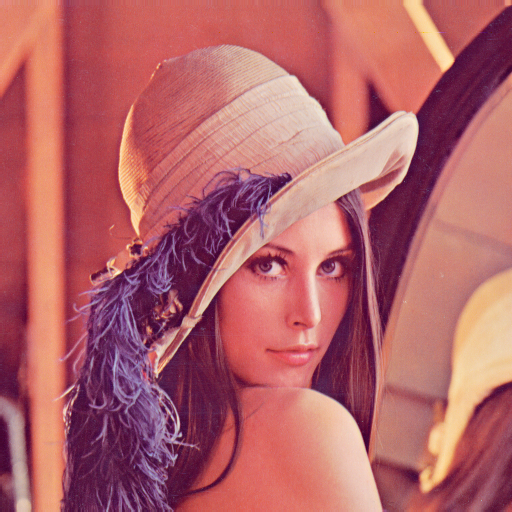

In [5]:
BLOCK_SIZE = 8 
model_lossless = DCTAutoencoder(block_size=BLOCK_SIZE)
print(f"embedding_dimension = {model_lossless.embedding_dimension}")
print(f"is nn.Module: {isinstance(model_lossless, torch.nn.Module)}")

batch = to_tensor(image).unsqueeze(0)  # (1, 3, H, W), values in [0, 1]
print(f"{batch.shape=}")

enc = model_lossless.encode(batch)
print(f"{enc.shape=}")

rec = model_lossless.decode(enc)
max_error = (batch - rec).abs().max().item()
print(f"Max reconstruction error: {max_error:.6f}")

torch.testing.assert_close(batch, rec, rtol=1e-3, atol=1e-3)
to_pil_image(rec.squeeze(0))

### Part 2 — Lossy compression (JPEG-like)

Keeping fewer low-frequency coefficients for chrominance than luminance mirrors how JPEG exploits the eye's lower sensitivity to colour detail.

In [6]:
NUM_LUMINANCE_CHANNELS = 10  # keep 10 lowest Y  frequencies (of 64)
NUM_CHROMINANCE_CHANNELS = 6  # keep  6 lowest Cb/Cr frequencies (of 64)

model_lossy = DCTAutoencoder(
    block_size=BLOCK_SIZE,
    num_luminance_compressed_channels=NUM_LUMINANCE_CHANNELS,
    num_chrominance_compressed_channels=NUM_CHROMINANCE_CHANNELS,
)

print(f"Retained coefficient channels: {model_lossy.get_num_compressed_channels()}")
print(f"Full encoding channels: {BLOCK_SIZE**2 * 3}")

Retained coefficient channels: 22
Full encoding channels: 192


#### Encoding

In [7]:
dct_encodings = model_lossy.encode(batch)
print(f"{dct_encodings.shape=}")

dct_encodings.shape=torch.Size([1, 192, 64, 64])


#### Compression

In [8]:
compressed_encodings = model_lossy.compress(dct_encodings)
print(f"{compressed_encodings.shape=}")

compression_ratio = dct_encodings.numel() / compressed_encodings.numel()
print(f"{compression_ratio=:.2f}x")

compressed_encodings.shape=torch.Size([1, 22, 64, 64])
compression_ratio=8.73x


#### Decompression and decoding

decompressed_encodings.shape=torch.Size([1, 192, 64, 64])


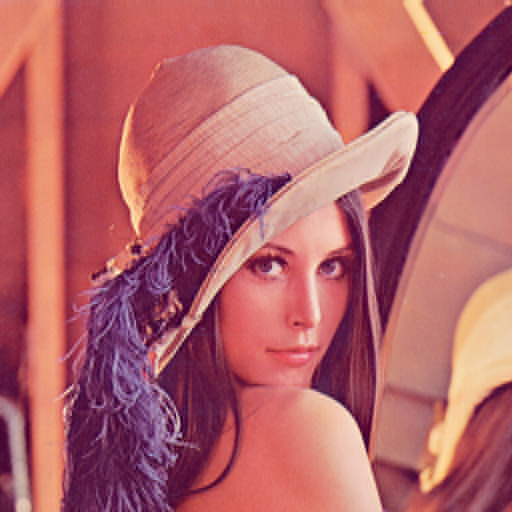

In [9]:
decompressed_encodings = model_lossy.decompress(compressed_encodings)
print(f"{decompressed_encodings.shape=}")

reconstructed_batch = model_lossy.decode(decompressed_encodings)
reconstructed_image = reconstructed_batch.squeeze(0)
to_pil_image(reconstructed_image.clamp(0, 1))

#### Side-by-side comparison

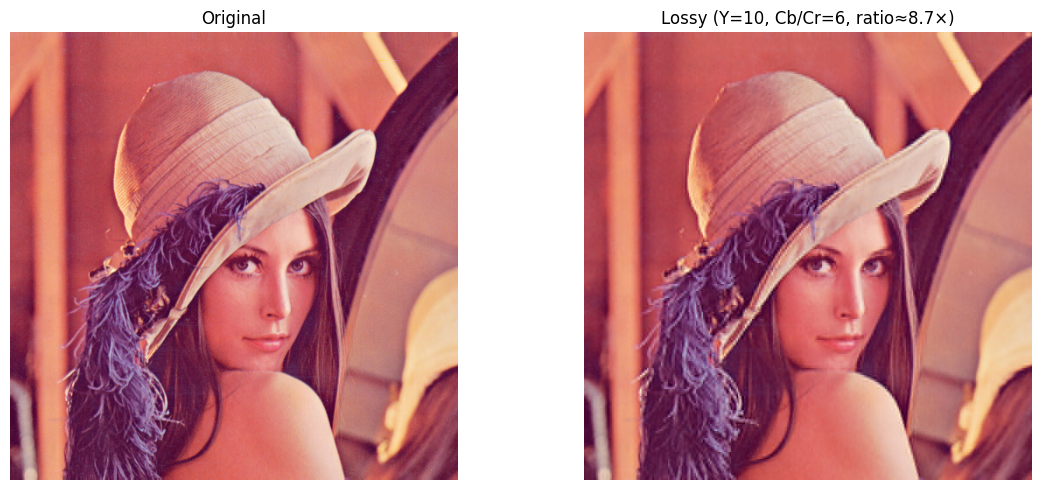

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(to_pil_image(reconstructed_image.clamp(0, 1)))
axes[1].set_title(
    f"Lossy (Y={NUM_LUMINANCE_CHANNELS}, Cb/Cr={NUM_CHROMINANCE_CHANNELS}, "
    f"ratio≈{compression_ratio:.1f}×)"
)
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Part 3 — Larger blocks and aggressive compression

The same API works for any block size. Below we use 16 × 16 blocks with a higher passband.

block_size=16, channels kept=128
encoding shape: (1, 768, 32, 32) → compressed: (1, 128, 32, 32)
compression ratio: 6.00x


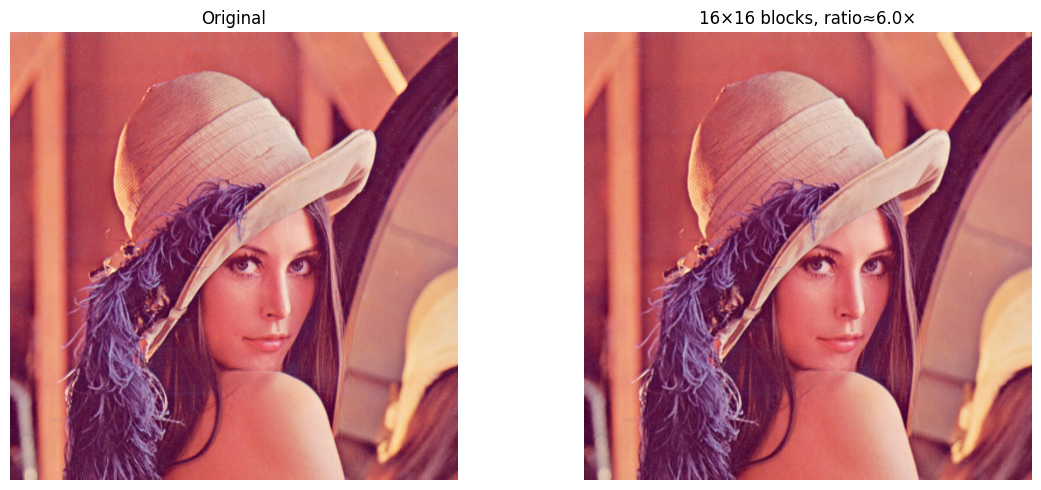

In [11]:
block_size_large = 16
num_lum_large = 96
num_chr_large = 16

batch_large = to_tensor(image).unsqueeze(0)

model_large = DCTAutoencoder(
    block_size=block_size_large,
    num_luminance_compressed_channels=num_lum_large,
    num_chrominance_compressed_channels=num_chr_large,
)

enc_large = model_large.encode(batch_large)
comp_large = model_large.compress(enc_large)
dec_large = model_large.decode(model_large.decompress(comp_large))

ratio_large = enc_large.numel() / comp_large.numel()
print(
    f"block_size={block_size_large}, channels kept={model_large.get_num_compressed_channels()}"
)
print(
    f"encoding shape: {tuple(enc_large.shape)} → compressed: {tuple(comp_large.shape)}"
)
print(f"compression ratio: {ratio_large:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(to_pil_image(dec_large.squeeze(0).clamp(0, 1)))
axes[1].set_title(f"16×16 blocks, ratio≈{ratio_large:.1f}×")
axes[1].axis("off")
plt.tight_layout()
plt.show()

---

## Compression Ratio Analysis

For a block size of $N = 8$ and an image of spatial resolution $H \times W$:

| Representation | Channels | Spatial size | Total values |
|----------------|----------|--------------|--------------|
| RGB input | 3 | $H \times W$ | $3HW$ |
| Full encoding | $3N^2 = 192$ | $\tfrac{H}{N} \times \tfrac{W}{N}$ | $3HW$ (lossless, same size) |
| Compressed encoding | $k_Y + 2k_C$ | $\tfrac{H}{N} \times \tfrac{W}{N}$ | $(k_Y + 2k_C)\tfrac{HW}{N^2}$ |

The **compression ratio** compared to the full encoding is:

$$
r = \frac{3N^2}{k_Y + 2k_C}
$$

**Example** ($k_Y = 10,\; k_C = 6,\; N = 8$):

$$
r = \frac{3 \times 64}{10 + 12} = \frac{192}{22} \approx 8.7\times
$$

This mirrors how JPEG chrominance subsampling (retaining fewer Cb/Cr coefficients than Y) exploits the human eye's lower sensitivity to colour detail.

In [12]:
N = BLOCK_SIZE
k_y = NUM_LUMINANCE_CHANNELS
k_c = NUM_CHROMINANCE_CHANNELS

full_channels = 3 * N**2
compressed_channels = k_y + 2 * k_c
analytical_ratio = full_channels / compressed_channels

print(f"Full encoding channels:     {full_channels}")
print(f"Compressed channels kept:   {compressed_channels}")
print(f"Analytical ratio r:         {analytical_ratio:.2f}×")
print(f"Observed ratio (from Part 2): {compression_ratio:.2f}×")

Full encoding channels:     192
Compressed channels kept:   22
Analytical ratio r:         8.73×
Observed ratio (from Part 2): 8.73×
